In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
read_1d = pd.read_csv('../data/1d-data.csv')
read_1d

,value,group
0,4.564090,cases
1,1040.947860,cases
2,3117.665150,cases
3,67.501829,cases
4,10096.092602,cases
5,27118.782664,cases
6,196.081681,cases
7,2061.140895,cases
8,35764.919601,cases
9,5899.126877,cases


In [3]:
read_1d.groupby('group').describe()

value                                                                 \
        count         mean           std        min         25%          50%   
group                                                                          
cases    10.0  8536.682325  12638.714401   4.564090  407.298226  2589.403022   
control  10.0  2802.916687   2815.496319  20.803818  204.466867  2351.109772   

                                    
                 75%           max  
group                               
cases    9046.851171  35764.919601  
control  5384.068996   6432.621452

In [4]:
read_1d.sort_values(['group','value'])

,value,group
0,4.564090,cases
3,67.501829,cases
6,196.081681,cases
1,1040.947860,cases
7,2061.140895,cases
2,3117.665150,cases
9,5899.126877,cases
4,10096.092602,cases
5,27118.782664,cases
8,35764.919601,cases


group
cases      [[Axes(0.125,0.11;0.775x0.77)]]
control    [[Axes(0.125,0.11;0.775x0.77)]]
dtype: object

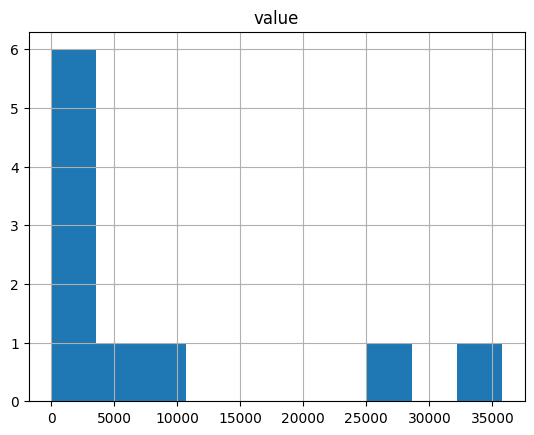

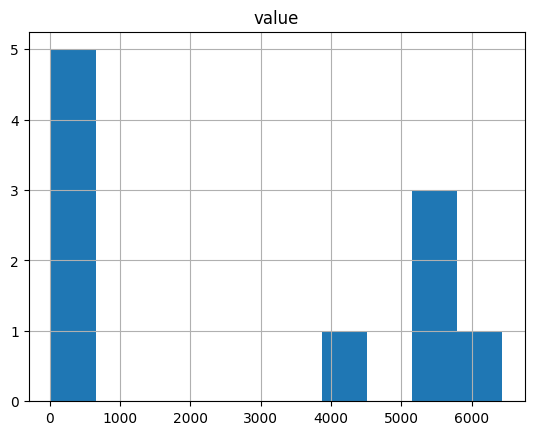

In [5]:
read_1d.groupby('group').hist()

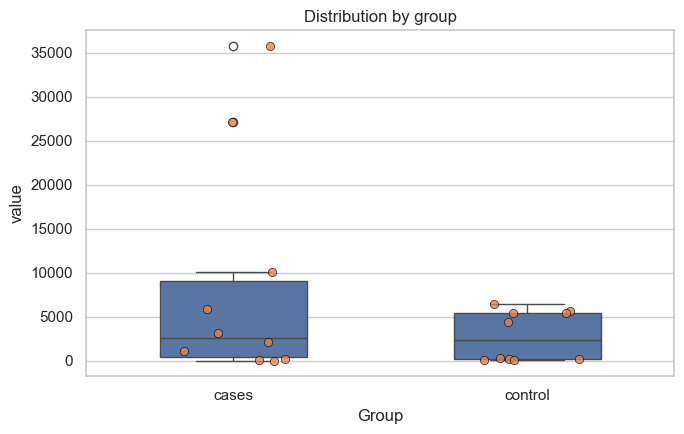

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

read_1d = pd.read_csv('../data/1d-data.csv')

# create figs directory if it doesn't exist
Path("figs").mkdir(parents=True, exist_ok=True)

df = read_1d.copy()
df["group"] = df["group"].astype(str).str.strip()
df["value"] = pd.to_numeric(df["value"], errors="coerce")

plt.close("all")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df,
    x="group",
    y="value",
    ax=ax,
    showfliers=True,
    width=0.5,
)

sns.stripplot(
    data=df,
    x="group",
    y="value",
    ax=ax,
    jitter=0.18,
    size=6,
    alpha=0.8,
    linewidth=0.5,
    edgecolor="black",
)

# Log scale to avoid misleading compression given extreme skew
# ax.set_yscale("log")

ax.set_xlabel("Group")
# ax.set_ylabel("Value (log scale)")
ax.set_title("Distribution by group")

fig.tight_layout()
# fig.savefig('figs/plot_1d.png')